# Straight 1s — how many dimensions, and can new points shrink that number?

Three steps:

1. **Pick out the straight 1s.** Only the plain single-stroke 1: tilted however it likes, thick
   or thin, but no top flag, no base bar, no detached specks, no hooked or curved stroke.
2. **Measure their dimension with PCA.** How many straight-line directions in 784-d space are
   needed to hold most of the variation?
3. **Add new 1s to push that number down.** Each new point has to pass seven checks that it's
   still a straight 1, sit within 1.89 of a real one, and be a real change rather than a
   near-copy. Keep adding until nothing helps any more.

Helpers live in `straight_ones.py`. Everything is raw pixels, 0 to 1.

In [1]:
import numpy as np, pickle, matplotlib.pyplot as plt
from pathlib import Path
import mnist, straight_ones as so

FIG = Path("figures"); CACHE = Path("data")
Xr, y = mnist.load("train"); X = Xr.reshape(len(Xr), -1) / 255.0
Xt, yt = mnist.load("test");  Xt = Xt.reshape(len(Xt), -1) / 255.0
ones = X[y == 1]; n = len(ones)
print(f"{n} training 1s, {(yt == 1).sum()} test 1s, 784 pixels each")

6742 training 1s, 1135 test 1s, 784 pixels each


## 1. A score for "how far from a straight 1"

For every 1, find the **ideal straight stroke** that best matches it: a rounded bar (a capsule)
with six knobs — where its centre is (2), how much it leans, how long it is, how thick it is,
and how soft its edge is. A least-squares fit turns the knobs until the bar overlaps the image
as well as it possibly can.

The score is the pixel distance between the image and that best bar. It's in **the same units
as the 1.89** from `OnesManifold.ipynb`, so the two can be compared directly. Anything a straight
bar can't draw — a flag, a base bar, a hook, a curve — is left over and pushes the score up.

In [2]:
cache = CACHE / "straight_fit.npz"
if cache.exists():
    f = np.load(cache); P, E = f["P"], f["E"]
else:
    fits = [so.stroke_fit(v) for v in ones]                 # ~20 s
    P = np.array([p for p, _ in fits]); E = np.array([e for _, e in fits])
    np.savez(cache, P=P, E=E)
pieces = np.array([so.n_pieces(v) for v in ones])
print("distance to the best straight stroke, percentiles:")
for q, v in zip([5, 25, 50, 75, 90, 95, 99], np.percentile(E, [5, 25, 50, 75, 90, 95, 99])):
    print(f"  {q:3d}%  {v:.2f}")
print(f"\n1s with more than one piece of ink: {(pieces > 1).sum()} ({100*(pieces > 1).mean():.1f}%)")

distance to the best straight stroke, percentiles:
    5%  0.93
   25%  1.29
   50%  1.62
   75%  2.07
   90%  2.63
   95%  3.23
   99%  5.27

1s with more than one piece of ink: 287 (4.3%)


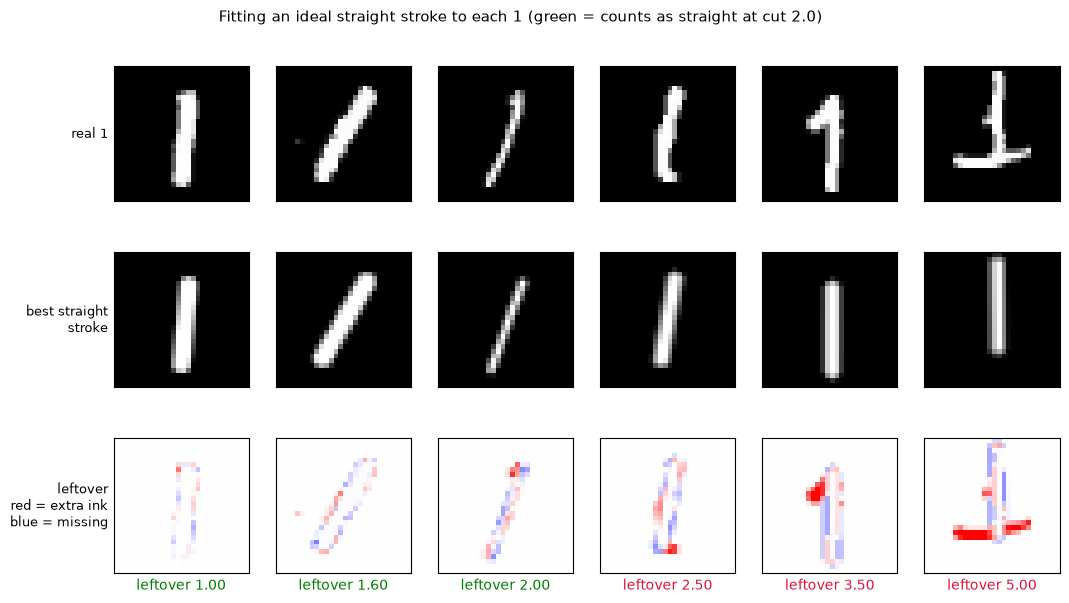

In [3]:
# what the fit looks like: easy, middling and failing cases
pick = [np.argsort(np.abs(E - v))[0] for v in [1.0, 1.6, 2.0, 2.5, 3.5, 5.0]]
fig, ax = plt.subplots(3, 6, figsize=(11, 6.2))
for j, i in enumerate(pick):
    fit = so.render_stroke(P[i])
    ax[0, j].imshow(ones[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax[1, j].imshow(fit.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax[2, j].imshow((ones[i] - fit).reshape(28, 28), cmap="bwr", vmin=-1, vmax=1)
    ax[2, j].text(0.5, -0.12, f"leftover {E[i]:.2f}", transform=ax[2, j].transAxes, ha="center",
                  fontsize=10, color="green" if E[i] < so.STRAIGHT_CUT else "crimson")
for r, t in enumerate(["real 1", "best straight\nstroke", "leftover\nred = extra ink\nblue = missing"]):
    ax[r, 0].set_ylabel(t, fontsize=9, rotation=0, ha="right", va="center")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.suptitle("Fitting an ideal straight stroke to each 1 (green = counts as straight at cut 2.0)", fontsize=11)
fig.subplots_adjust(left=0.13, right=0.99, top=0.9, bottom=0.06, hspace=0.25)
fig.savefig(FIG / "straight_fit.png", dpi=110); plt.show()

## 2. Choosing the cutoff — five tries

Where does "straight" end? No formula answers that, so we look. For each candidate cutoff, show
the 1s sitting **just under it**: the worst ones that would still get in. Raise the cutoff until
those borderline admissions stop looking like plain straight 1s.

What each try showed:

| cut | kept | the borderline 1s look like |
|---|---|---|
| 1.6 | 3174 | all clean straight strokes. Too strict: thick straight 1s are cut just for being thick |
| 1.8 | 3998 | still all straight |
| **2.0** | **4685** | mostly straight, the first faint bends appear. **Chosen** |
| 2.2 | 5170 | noticeable curves and small feet |
| 2.4 | 5518 | hooks, `(`-shaped curves, the odd flag |

The rule: **leftover < 2.0 and one piece of ink.** (The leftover scales a little with ink, so a very
heavy straight stroke can miss the cut. That costs a few good 1s, but doesn't let bad ones in.)

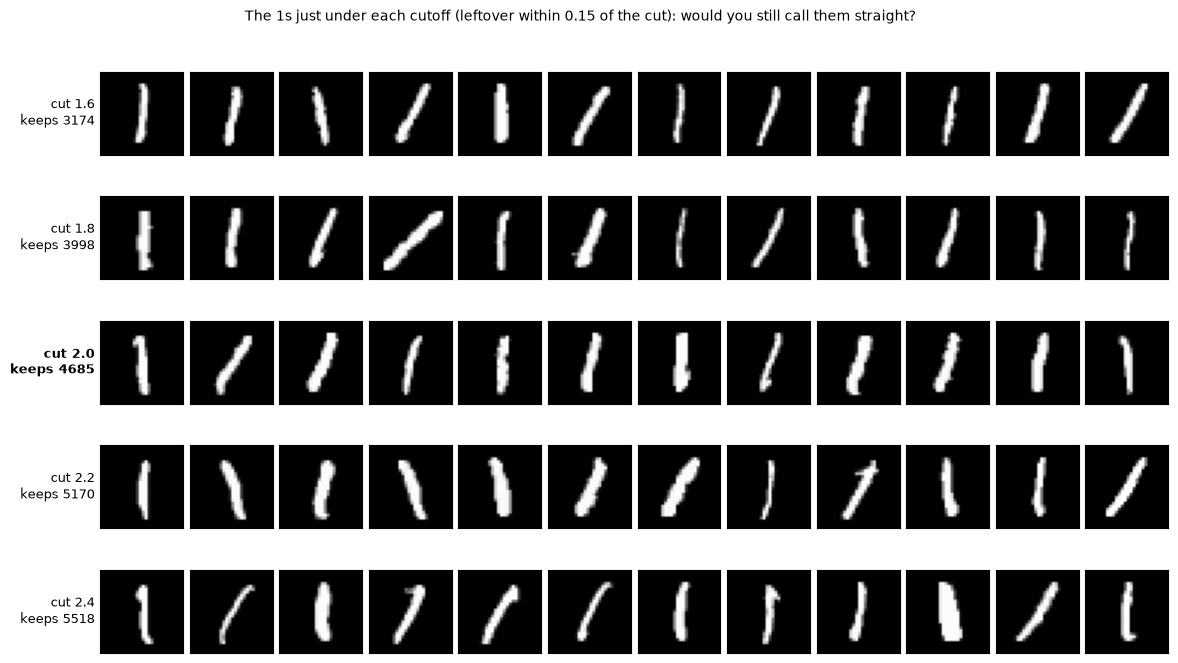

straight 1s: 4685 of 6742 (69%)


In [4]:
cuts = [1.6, 1.8, 2.0, 2.2, 2.4]
fig, ax = plt.subplots(len(cuts), 12, figsize=(12, 1.25 * len(cuts) + 0.6))
for r, c in enumerate(cuts):
    keep = (E < c) & (pieces == 1)
    border = np.where(keep & (E >= c - 0.15))[0]
    border = np.random.default_rng(r).choice(border, 12, replace=False)
    for j, i in enumerate(border):
        ax[r, j].imshow(ones[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax[r, j].set_xticks([]); ax[r, j].set_yticks([])
    ax[r, 0].set_ylabel(f"cut {c}\nkeeps {keep.sum()}", fontsize=9, rotation=0, ha="right", va="center",
                        fontweight="bold" if c == so.STRAIGHT_CUT else "normal")
fig.suptitle("The 1s just under each cutoff (leftover within 0.15 of the cut): would you still call them straight?",
             fontsize=10)
fig.subplots_adjust(left=0.1, right=0.99, top=0.91, bottom=0.02, hspace=0.12, wspace=0.08)
fig.savefig(FIG / "straight_cutoffs.png", dpi=110); plt.show()

straight = (E < so.STRAIGHT_CUT) & (pieces == 1)
S = ones[straight]
print(f"straight 1s: {len(S)} of {n} ({100*len(S)/n:.0f}%)")

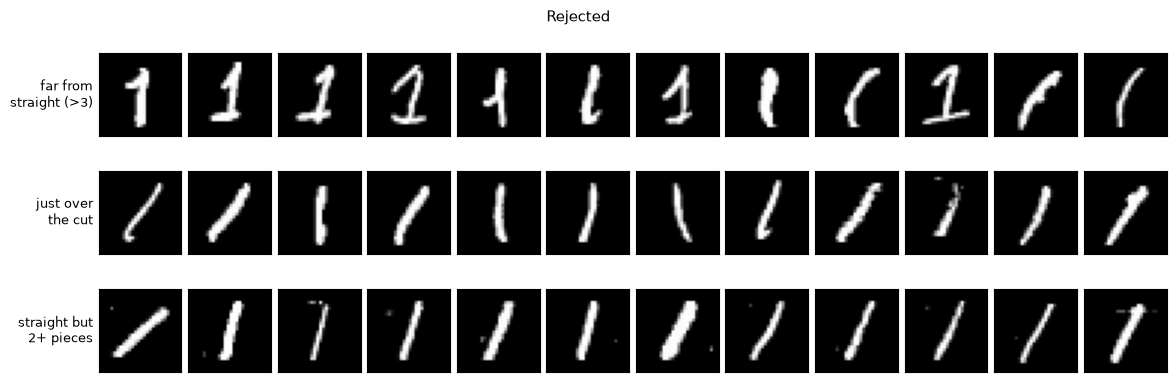

In [5]:
# and what got thrown out, most un-straight first
out = np.where(~straight)[0]
rng = np.random.default_rng(0)
show = np.concatenate([rng.choice(out[E[out] > 3], 12, replace=False),
                       rng.choice(out[(E[out] >= 2.0) & (E[out] < 2.6)], 12, replace=False),
                       rng.choice(out[(pieces[out] > 1) & (E[out] < 2.0)], 12, replace=False)])
fig, ax = plt.subplots(3, 12, figsize=(12, 3.9))
for a, i in zip(ax.ravel(), show):
    a.imshow(ones[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1); a.set_xticks([]); a.set_yticks([])
for r, t in enumerate(["far from\nstraight (>3)", "just over\nthe cut", "straight but\n2+ pieces"]):
    ax[r, 0].set_ylabel(t, fontsize=9, rotation=0, ha="right", va="center")
fig.suptitle("Rejected", fontsize=11)
fig.subplots_adjust(left=0.1, right=0.99, top=0.9, bottom=0.02, hspace=0.1, wspace=0.08)
plt.show()

## 3. PCA dimension of the straight 1s

**What PCA measures.** Take the average straight 1. Every real one differs from it by some
784-number difference. PCA finds the single direction along which those differences are
biggest, then the next biggest *at right angles to it*, and so on. Each direction's
**eigenvalue** is how much of the total spread it carries.

"Dimension at 95%" = how many of those directions you need before they hold 95% of all the
spread. It's a **flat** measure: it asks how many straight axes a box needs to hold the cloud.
A curved sheet needs more straight axes than its true dimension. That's the gap between 71 PCs
and TwoNN's ~11 in `OnesManifold` Part IX.

In [6]:
cnt_all, w_all = so.pca_stats(ones)
cnt_S, w_S = so.pca_stats(S)
Tt = Xt[yt == 1]
Et = np.array([so.stroke_fit(v)[1] for v in Tt]); pt = np.array([so.n_pieces(v) for v in Tt])
T = Tt[(Et < so.STRAIGHT_CUT) & (pt == 1)]            # held-out straight 1s, never touched below
cnt_T, w_T = so.pca_stats(T)
print(f"{'':22s} {'n':>5s}  " + "  ".join(f"{int(f*100)}%" for f in so.FRACS))
for nm, N, c in [("all train 1s", n, cnt_all), ("straight train 1s", len(S), cnt_S),
                 ("straight test 1s", len(T), cnt_T)]:
    print(f"{nm:22s} {N:5d}  " + "  ".join(f"{c[f]:3d}" for f in so.FRACS))
print(f"\nfirst 10 eigenvalues (share of spread): " + " ".join(f"{v:.3f}" for v in w_S[:10] / w_S.sum()))

                           n  80%  90%  95%  99%
all train 1s            6742   14   36   71  176
straight train 1s       4685    9   24   50  133
straight test 1s         827    9   23   47  118

first 10 eigenvalues (share of spread): 0.381 0.161 0.074 0.059 0.038 0.029 0.026 0.018 0.014 0.012


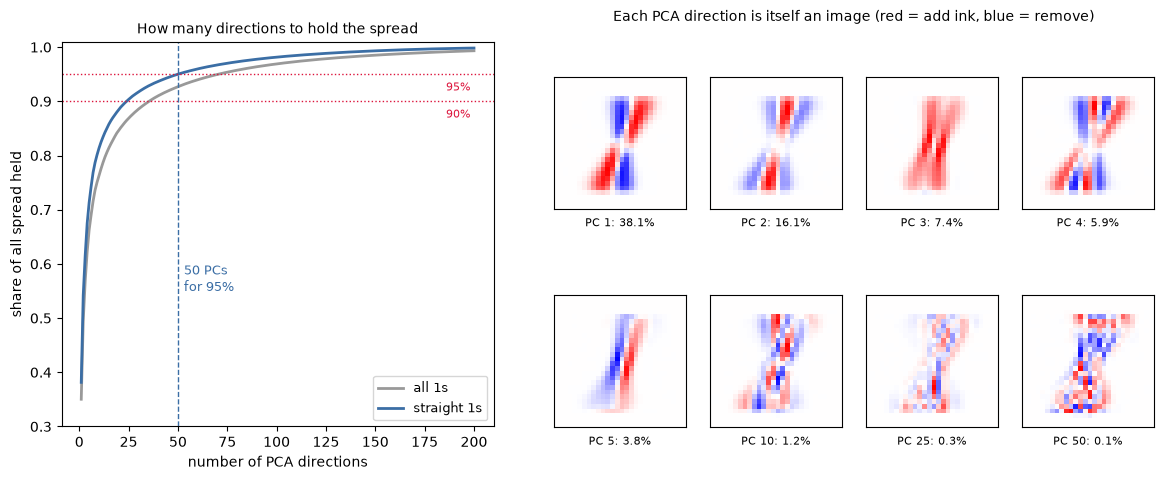

In [7]:
mu_S, _, V_S = so.pca(S)
fig = plt.figure(figsize=(12, 5.2))
a = fig.add_axes([0.06, 0.14, 0.36, 0.74])
for nm, w, c in [("all 1s", w_all, "#999999"), ("straight 1s", w_S, "#3b6ea5")]:
    a.plot(np.arange(1, 201), (np.cumsum(w) / w.sum())[:200], color=c, lw=2, label=nm)
for f in (0.9, 0.95):
    a.axhline(f, color="crimson", ls=":", lw=1)
    a.text(198, f - 0.03, f"{int(f*100)}%", color="crimson", ha="right", fontsize=8)
a.axvline(cnt_S[0.95], color="#3b6ea5", ls="--", lw=1)
a.text(cnt_S[0.95] + 3, 0.55, f"{cnt_S[0.95]} PCs\nfor 95%", color="#3b6ea5", fontsize=9)
a.set_xlabel("number of PCA directions"); a.set_ylabel("share of all spread held")
a.set_ylim(0.3, 1.01); a.legend(loc="lower right", fontsize=9)
a.set_title("How many directions to hold the spread", fontsize=10)
# the directions themselves are images
for j, k in enumerate([0, 1, 2, 3, 4, 9, 24, 49]):
    ax = fig.add_axes([0.47 + (j % 4) * 0.13, 0.52 - (j // 4) * 0.42, 0.11, 0.33])
    v = V_S[:, k]; m = np.abs(v).max()
    ax.imshow(v.reshape(28, 28), cmap="bwr", vmin=-m, vmax=m); ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, -0.13, f"PC {k+1}: {100*w_S[k]/w_S.sum():.1f}%", transform=ax.transAxes,
            ha="center", fontsize=8)
fig.text(0.72, 0.92, "Each PCA direction is itself an image (red = add ink, blue = remove)",
         ha="center", fontsize=10)
fig.savefig(FIG / "straight_pca.png", dpi=110); plt.show()

The first few directions are clearly **lean** (red on one side, blue on the other), **thickness**
and **shifting up/down or sideways**. By PC 25 and PC 50 the images are speckle: pixel-scale
wobble in each person's stroke. That speckle is what the tail of 25-50 directions is made of.

## 4. What adding a point can and can't do — the one idea to hold onto

PCA's spread is a **sum over points**: each point adds its own squared distance from the average,
split across the directions. So:

- **A new point can never cancel an old point's contribution.** Squares are never negative.
  The old points' spread in the small directions (the tail) is fixed, whatever we add.
- The only lever is to **make the big directions bigger**: add points whose difference from the
  average lies *almost entirely* in the top directions, and as far out along them as allowed.
  Then the tail becomes a smaller *share* of the total, and fewer PCs reach 95%.

So "adding points to reduce dimension" really means **diluting the tail**. Whether that's cheating
or a real discovery depends on one thing: are the new points real straight 1s the sample just
didn't happen to contain? Hence the checks, and the held-out test in section 7.

"Where things diverge the most" does show up in the method. For each real 1 we can name its
own **tail part**, the bit of it lying in the small directions. That's where it departs from the
flat PCA picture.

## 5. What counts as a valid new 1 — seven checks, calibrated

Every candidate must pass all seven. The seventh, **clean**, was added after a first run: points
built by trimming away a 1's tail came out with a faint **X-shaped ghost**, a second stroke
leaning the other way. That's the same cross-fade ghost as `OnesManifold` Part XII. The first six
checks let it through, and looking at the images caught it. Real 1s have essentially no ink more
than 2 px from their stroke, so that's now required of new points too. (This check also moved the
hand-variation warps from cubic to bilinear resampling: cubic leaves a faint ripple around the
stroke that real MNIST never has.) Each is measured on populations whose answer we already know.

In [8]:
ck = so.Checker(S, X, y)
print(f"crisp range from real straight 1s: TV/ink in [{ck.tv_lo:.3f}, {ck.tv_hi:.3f}],"
      f" grey fraction <= {ck.gf_hi:.3f}")
rng = np.random.default_rng(0)
iu = rng.choice(len(S), (300, 2))
dd = np.linalg.norm(S[iu[:, 0]] - S[iu[:, 1]], axis=1)
far = iu[dd > 6][:150]
u = rng.normal(size=(150, 784)); u /= np.linalg.norm(u, axis=1, keepdims=True)
Tbent = Tt[(Et >= so.STRAIGHT_CUT) & (pt == 1)]
pops = [("train straight 1s (should pass)", S[rng.choice(len(S), 150, replace=False)]),
        ("TEST straight 1s  (should pass)", T[:150]),
        ("test bent/serif 1s (should fail)", Tbent[:150]),
        ("test 7s            (should fail)", Xt[yt == 7][:150]),
        ("average of 2 far 1s (should fail)", (S[far[:, 0]] + S[far[:, 1]]) / 2),
        ("1 + noise of 1.89   (should fail)", np.clip(S[:150] + so.THETA * u, 0, 1))]
print(f"\n{'':36s}" + "".join(f"{c:>11s}" for c in so.CHECK_NAMES) + f"{'ALL 7':>10s}")
for nm, Q in pops:
    ok, _ = ck.check(Q, full=True)
    print(f"{nm:36s}" + "".join(f"{100*m:10.0f}%" for m in ok.mean(0)) + f"{100*ok.all(1).mean():9.0f}%")

# the case that motivated check 7: a 1 with its tail removed (PCA's own "denoise")
mu_, w_, V_ = so.pca(S); k_ = so.n_for(w_, 0.95)
Z_ = S[:150] - mu_; trimmed = np.clip(mu_ + (Z_ @ V_[:, :k_]) @ V_[:, :k_].T, 0, 1)
ok, _ = ck.check(trimmed, full=True)
print(f"{'1 with its whole tail removed':36s}" + "".join(f"{100*m:10.0f}%" for m in ok.mean(0))
      + f"{100*ok.all(1).mean():9.0f}%")

crisp range from real straight 1s: TV/ink in [0.592, 1.646], grey fraction <= 0.650

                                        in cube kNN says 1  near real   straight    1 piece      crisp      clean     ALL 7
train straight 1s (should pass)            100%       100%       100%       100%       100%        99%        99%       98%
TEST straight 1s  (should pass)            100%       100%        86%       100%       100%        98%       100%       85%
test bent/serif 1s (should fail)           100%        94%        19%         0%       100%        95%       100%        0%
test 7s            (should fail)           100%         1%         0%         0%       100%        96%       100%        0%
average of 2 far 1s (should fail)          100%       100%         0%        38%        99%         6%       100%        0%
1 + noise of 1.89   (should fail)          100%       100%       100%        47%        33%        79%         0%        0%
1 with its whole tail removed              100%

How to read the table:

- **Nothing that should fail gets through.** Bent 1s, 7s, cross-fades and noisy 1s all score 0%.
- **Real training straight 1s pass ~99%.**
- **Held-out test straight 1s pass less often**, and almost all of that loss is one check,
  *near real*. An unseen straight 1 is often more than 1.89 from every training straight 1 —
  another sign the sample is sparse. That check is **deliberately strict**. It's what stops new
  points from wandering off into space nobody has drawn, so we accept losing some true 1s to it.

## 6. Adding points, greedily

Each round:

1. Fit PCA to everything so far. Call the 95% count **k**; the target is **k − 1**.
2. Make candidates from every **real** straight 1 (never from added ones, so nothing can drift
   away in a chain):
   - **trim**: remove part of the 1's own tail part (its small-direction wobble), moving at most 1.89
   - **push**: move it further out along its own big-direction part, by 0.94 or 1.89
   - **hand variations**: rotate ±2°/±4°, shift 1 px, stretch ±8% in length, thin/thicken
3. Keep only candidates that pass all seven checks and sit **at least 1.17** from every point
   already in the set. 1.17 is the 5th percentile of real nearest-neighbour gaps, so no
   near-copies.
4. Score each by how much it would shrink the spread outside the top k − 1. Add the best 100.
5. Stop when no valid candidate helps, or the 95% count hasn't moved for 6 rounds.

**Control:** add the same number of *randomly chosen* valid hand-variations. That separates
"aimed at the tail" from "just more points". Cached, because the full run takes about an hour.

In [9]:
Ssq = (S ** 2).sum(1)
Dss = np.sqrt(np.maximum(Ssq[:, None] + Ssq[None] - 2 * S @ S.T, 0)); np.fill_diagonal(Dss, 1e9)
nnS = Dss.min(1); min_sep = np.percentile(nnS, 5); del Dss
print(f"straight 1s: mean nearest-neighbour gap {nnS.mean():.2f}, 5th percentile {min_sep:.2f} (= min_sep)")

pool_f = CACHE / "straight_pool.pkl"
if pool_f.exists():
    pool = pickle.load(open(pool_f, "rb"))
else:
    Q, kind, frm = so.warp_pool(S)                               # ~3 min to check
    ok, _ = ck.check(Q); v = ok.all(1)
    pool = dict(Q=Q[v], kind=kind[v], frm=frm[v], tried={k: int((kind == k).sum()) for k in np.unique(kind)})
    pickle.dump(pool, open(pool_f, "wb"))
print("\nhand variations that pass all seven checks:")
for k in np.unique(pool["kind"]):
    print(f"  {k:8s} {(pool['kind'] == k).sum():6d}")

straight 1s: mean nearest-neighbour gap 1.64, 5th percentile 1.17 (= min_sep)

hand variations that pass all seven checks:
  rotate    14269
  shift      4887
  stretch    7241
  thicken    6543


In [10]:
aug_f = CACHE / "straight_aug.pkl"
if aug_f.exists():
    A = pickle.load(open(aug_f, "rb"))
else:
    added, akind, hist = so.augment(S, pool, ck, min_sep, batch=100, max_rounds=80, patience=6)
    A = dict(added=added, akind=akind, hist=hist); pickle.dump(A, open(aug_f, "wb"))
added, akind, hist = A["added"], A["akind"], A["hist"]
print(f"{'added':>6s} {'90%':>4s} {'95%':>4s} {'99%':>4s}   picked this round")
for h in hist:
    print(f"{h['n_added']:6d} {h['k90']:4d} {h['k95']:4d} {h['k99']:4d}   "
          + ", ".join(f"{k} {v}" for k, v in h["kinds"].items()))

 added  90%  95%  99%   picked this round
     0   24   50  133   
   100   24   49  132   rotate 78, thicken 22
   200   23   49  131   rotate 69, shift 1, thicken 30
   300   23   48  130   rotate 72, shift 4, thicken 24
   400   22   47  130   rotate 71, shift 2, thicken 27
   500   22   47  129   rotate 71, shift 2, thicken 27
   600   22   46  129   rotate 71, shift 7, thicken 22
   700   22   46  128   rotate 68, shift 6, thicken 24, trim 2
   800   21   45  128   rotate 69, shift 3, thicken 28
   900   21   45  127   rotate 54, shift 14, thicken 31, trim 1
  1000   21   45  127   rotate 66, shift 11, thicken 23
  1100   21   44  127   rotate 65, shift 12, thicken 23
  1200   21   44  126   rotate 64, shift 13, thicken 22, trim 1
  1300   20   44  126   rotate 65, shift 13, stretch 1, thicken 21
  1400   20   43  125   rotate 63, shift 19, stretch 1, thicken 17
  1500   20   43  125   rotate 58, shift 16, thicken 26
  1600   20   43  125   rotate 62, shift 15, thicken 23
  1700  

In [11]:
# control: the same number of random valid hand-variations, same min_sep rule
ctl_f = CACHE / "straight_ctl.pkl"
if ctl_f.exists():
    C = pickle.load(open(ctl_f, "rb"))
else:
    rng = np.random.default_rng(1)
    order = rng.permutation(len(pool["Q"]))
    cur, picked = S.copy(), []
    for i in order:
        if len(picked) >= len(added): break
        q = pool["Q"][i]
        if np.sqrt(max(((cur - q) ** 2).sum(1).min(), 0)) < min_sep: continue
        picked.append(i); cur = np.vstack([cur, q])
    C = dict(idx=np.array(picked))
    C["curve"] = [(m, so.pca_stats(np.vstack([S, pool["Q"][C["idx"][:m]]]))[0])
                  for m in range(0, len(picked) + 1, 100)]
    pickle.dump(C, open(ctl_f, "wb"))
print("random valid additions:")
for m, c in C["curve"][::3]:
    print(f"  +{m:5d}  PCs 90/95/99 = {c[0.9]}/{c[0.95]}/{c[0.99]}")

random valid additions:
  +    0  PCs 90/95/99 = 24/50/133
  +  300  PCs 90/95/99 = 24/50/133
  +  600  PCs 90/95/99 = 24/50/134
  +  900  PCs 90/95/99 = 24/50/134
  + 1200  PCs 90/95/99 = 24/50/134
  + 1500  PCs 90/95/99 = 24/50/134
  + 1800  PCs 90/95/99 = 24/50/134
  + 2100  PCs 90/95/99 = 24/50/134
  + 2400  PCs 90/95/99 = 24/50/134
  + 2700  PCs 90/95/99 = 24/50/133
  + 3000  PCs 90/95/99 = 24/49/133
  + 3300  PCs 90/95/99 = 24/49/133


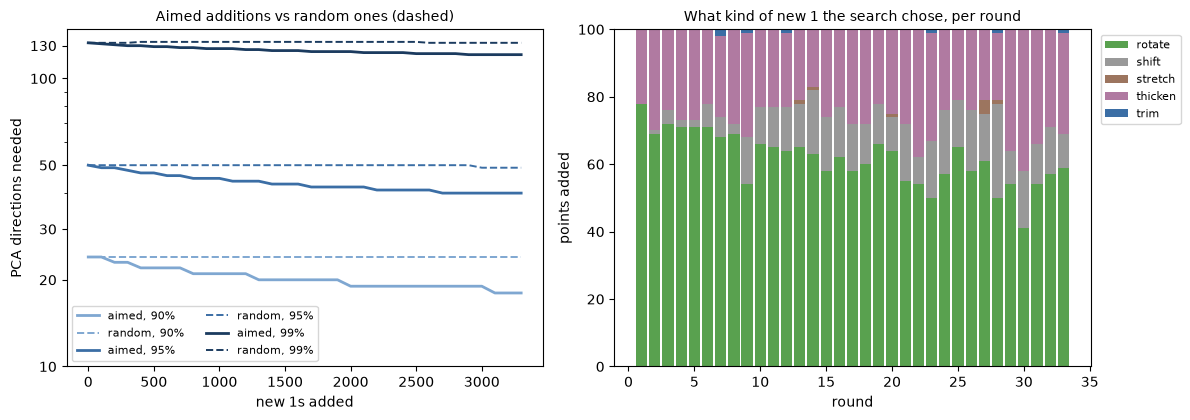

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
na = [h["n_added"] for h in hist]
for f, c in [(0.90, "#7fa7d1"), (0.95, "#3b6ea5"), (0.99, "#1b3b5f")]:
    key = f"k{int(f*100)}"
    ax[0].plot(na, [h[key] for h in hist], "-", color=c, lw=2, label=f"aimed, {int(f*100)}%")
    ax[0].plot([m for m, _ in C["curve"]], [cc[f] for _, cc in C["curve"]], "--", color=c, lw=1.4,
               label=f"random, {int(f*100)}%")
ax[0].set_xlabel("new 1s added"); ax[0].set_ylabel("PCA directions needed")
ax[0].set_title("Aimed additions vs random ones (dashed)", fontsize=10); ax[0].legend(fontsize=8, ncol=2)
ax[0].set_yscale("log"); ax[0].set_yticks([10, 20, 30, 50, 100, 130]); ax[0].set_yticklabels([10, 20, 30, 50, 100, 130])
kinds = sorted({k for h in hist for k in h["kinds"]})
bottom = np.zeros(len(hist) - 1)
cols = dict(trim="#3b6ea5", push="#e08a2c", rotate="#59a14f", thicken="#b07aa1", stretch="#9c755f", shift="#999999")
for k in kinds:
    v = np.array([h["kinds"].get(k, 0) for h in hist[1:]])
    ax[1].bar(np.arange(1, len(hist)), v, bottom=bottom, color=cols.get(k, "k"), label=k, width=0.85)
    bottom += v
ax[1].set_xlabel("round"); ax[1].set_ylabel("points added")
ax[1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
ax[1].set_title("What kind of new 1 the search chose, per round", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / "straight_augment_curve.png", dpi=110); plt.show()

## What the added 1s look like

Each new point next to the real 1 it came from, plus the difference (red = ink added,
blue = ink removed). Under each: its distance from that source, and its leftover from the
ideal straight stroke. A trim's difference **is** the tail part it removed. Look at it:
that's the pixel wobble PCA was spending its 25-50 extra directions on.

added points: 3300   distance to nearest real straight 1: median 1.53, max 1.89 (limit 1.89)
leftover from a straight stroke: added median 1.15, real straight 1s median 1.43
sharpness TV/ink: real 1.027, added 0.940


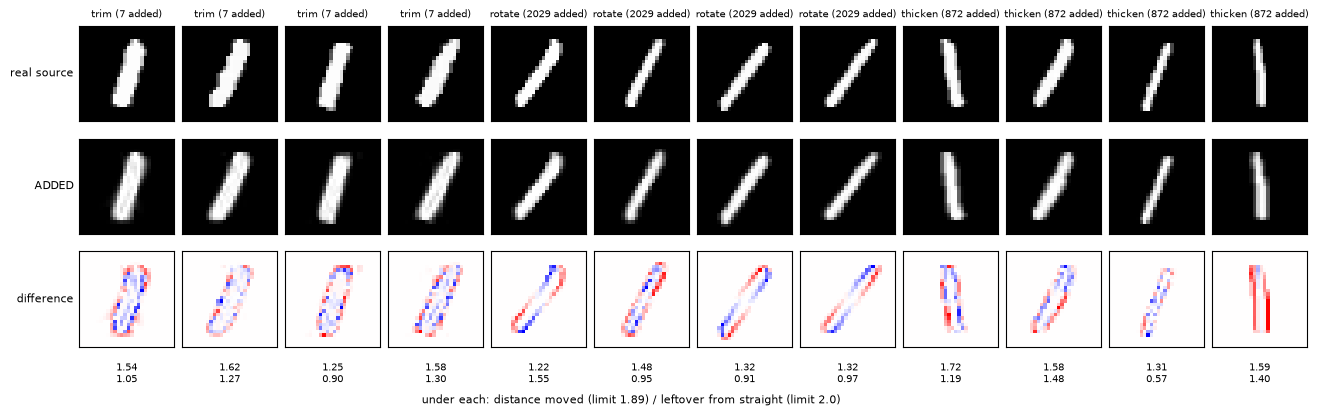

In [13]:
src_d, src_i = so.nearest(added, S)
res_add = np.array([so.stroke_fit(v)[1] for v in added[::max(1, len(added) // 400)]])
print(f"added points: {len(added)}   distance to nearest real straight 1: "
      f"median {np.median(src_d):.2f}, max {src_d.max():.2f} (limit {so.THETA})")
print(f"leftover from a straight stroke: added median {np.median(res_add):.2f}, "
      f"real straight 1s median {np.median(E[straight]):.2f}")
tv_r, tv_a = so.tv_per_ink(S).mean(), so.tv_per_ink(added).mean()
print(f"sharpness TV/ink: real {tv_r:.3f}, added {tv_a:.3f}")

rng = np.random.default_rng(3)
ks = [k for k in ["trim", "push", "rotate", "thicken", "stretch"] if (akind == k).any()]
rows = []
for k in ks:
    idx = np.where(akind == k)[0]
    rows += [(k, i) for i in rng.choice(idx, min(4, len(idx)), replace=False)]
rows = rows[:12]
fig, ax = plt.subplots(3, len(rows), figsize=(1.05 * len(rows) + 1.2, 4.3))
for j, (k, i) in enumerate(rows):
    s = S[src_i[i]]; d = added[i] - s; m = max(np.abs(d).max(), 1e-6)
    ax[0, j].imshow(s.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax[1, j].imshow(added[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax[2, j].imshow(d.reshape(28, 28), cmap="bwr", vmin=-m, vmax=m)
    ax[0, j].set_title(f"{k} ({(akind == k).sum()} added)", fontsize=7)
    ax[2, j].text(0.5, -0.16, f"{src_d[i]:.2f}\n{so.stroke_fit(added[i])[1]:.2f}", transform=ax[2, j].transAxes,
                  ha="center", va="top", fontsize=7)
for r, t in enumerate(["real source", "ADDED", "difference"]):
    ax[r, 0].set_ylabel(t, fontsize=8, rotation=0, ha="right", va="center")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
fig.text(0.5, 0.015, "under each: distance moved (limit 1.89) / leftover from straight (limit 2.0)",
         ha="center", fontsize=8)
fig.subplots_adjust(left=0.1, right=0.99, top=0.9, bottom=0.14, hspace=0.12, wspace=0.08)
fig.savefig(FIG / "straight_added.png", dpi=120); plt.show()

## 7. The honest test: is the lower number a truer picture of straight 1s?

The count went down. But section 4 showed there are two ways that can happen:

- **Dilution**: the tail is still there, just outweighed. The old points' spread in the small
  directions hasn't changed at all.
- **Discovery**: the new PCA directions describe straight 1s *better*, so a straight 1 the process
  never saw needs fewer directions too.

The test separates them. Take the **827 held-out test straight 1s**, never used anywhere above.
For each k, measure how much of their spread lies **outside** the first k directions: once with
the original PCA, once with the augmented one. If the augmented directions are truer, the
test 1s' outside share drops.

In [14]:
mu0, w0, V0 = so.pca(S)
mu1, w1, V1 = so.pca(np.vstack([S, added]))
def outside(Q, mu, V, k):
    Z = Q - mu; return 1 - ((Z @ V[:, :k]) ** 2).sum() / (Z ** 2).sum()

# 1) dilution check: the REAL points' spread, split top vs tail, before and after
k1 = so.n_for(w1, 0.95)
for nm, mu, V in [("original PCA ", mu0, V0), ("augmented PCA", mu1, V1)]:
    Z = S - mu; tot = (Z ** 2).sum(); top = ((Z @ V[:, :k1]) ** 2).sum()
    print(f"{nm}: real straight 1s' spread outside the top {k1} = {100*(1-top/tot):.2f}%")
Z = added - mu1
print(f"added points' own spread outside the top {k1}      = "
      f"{100*(1-((Z @ V1[:, :k1])**2).sum()/(Z**2).sum()):.2f}%")

# 2) held-out test
ks = [5, 10, 15, 20, 25, 30, 40, 50, 60, 80]
print(f"\nheld-out test straight 1s: share of spread OUTSIDE the first k directions")
print(f"{'k':>4s} {'original':>9s} {'augmented':>10s}")
for k in ks:
    print(f"{k:4d} {100*outside(T, mu0, V0, k):8.2f}% {100*outside(T, mu1, V1, k):9.2f}%")
k0 = so.n_for(w0, 0.95)
print(f"\ntest 1s' spread held by the original's own 95% count ({k0} PCs): {100*(1-outside(T, mu0, V0, k0)):.1f}%")
print(f"test 1s' spread held by the augmented's own 95% count ({k1} PCs): {100*(1-outside(T, mu1, V1, k1)):.1f}%")

original PCA : real straight 1s' spread outside the top 40 = 6.33%
augmented PCA: real straight 1s' spread outside the top 40 = 6.34%
added points' own spread outside the top 40      = 2.90%

held-out test straight 1s: share of spread OUTSIDE the first k directions
   k  original  augmented
   5    28.88%     28.61%
  10    18.98%     18.97%
  15    14.65%     14.55%
  20    11.91%     11.87%
  25    10.03%      9.99%
  30     8.57%      8.55%
  40     6.58%      6.58%
  50     5.26%      5.24%
  60     4.29%      4.26%
  80     2.98%      2.93%

test 1s' spread held by the original's own 95% count (50 PCs): 94.7%
test 1s' spread held by the augmented's own 95% count (40 PCs): 93.4%


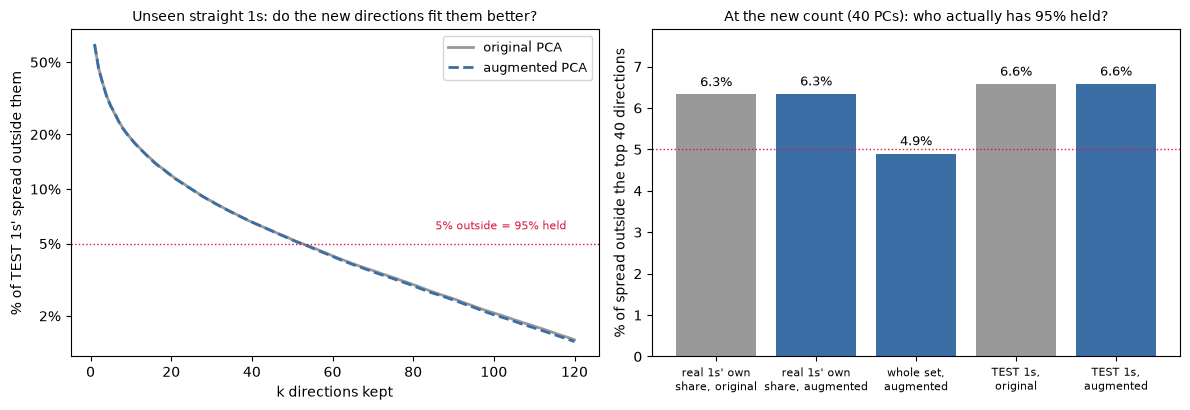

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
kk = np.arange(1, 121)
for nm, mu, V, c, ls in [("original PCA", mu0, V0, "#999999", "-"), ("augmented PCA", mu1, V1, "#3b6ea5", "--")]:
    ax[0].plot(kk, [100 * outside(T, mu, V, k) for k in kk], ls, color=c, lw=2, label=nm)
ax[0].axhline(5, color="crimson", ls=":", lw=1); ax[0].text(118, 6, "5% outside = 95% held", color="crimson",
                                                            ha="right", fontsize=8)
ax[0].set_yscale("log"); ax[0].set_xlabel("k directions kept")
ax[0].set_yticks([2, 5, 10, 20, 50]); ax[0].set_yticklabels(["2%", "5%", "10%", "20%", "50%"])
ax[0].minorticks_off()
ax[0].set_ylabel("% of TEST 1s' spread outside them")
ax[0].set_title("Unseen straight 1s: do the new directions fit them better?", fontsize=10)
ax[0].legend(fontsize=9)
lab = ["real 1s' own\nshare, original", "real 1s' own\nshare, augmented", "whole set,\naugmented",
       "TEST 1s,\noriginal", "TEST 1s,\naugmented"]
Zr0, Zr1 = S - mu0, S - mu1
allZ = np.vstack([S, added]) - mu1
vals = [100 * (1 - ((Zr0 @ V0[:, :k1]) ** 2).sum() / (Zr0 ** 2).sum()),
        100 * (1 - ((Zr1 @ V1[:, :k1]) ** 2).sum() / (Zr1 ** 2).sum()),
        100 * (1 - ((allZ @ V1[:, :k1]) ** 2).sum() / (allZ ** 2).sum()),
        100 * outside(T, mu0, V0, k1), 100 * outside(T, mu1, V1, k1)]
ax[1].set_ylim(0, max(vals) * 1.2)
b = ax[1].bar(range(5), vals, color=["#999999", "#3b6ea5", "#3b6ea5", "#999999", "#3b6ea5"])
for i, v in enumerate(vals): ax[1].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
ax[1].axhline(5, color="crimson", ls=":", lw=1)
ax[1].set_xticks(range(5)); ax[1].set_xticklabels(lab, fontsize=8)
ax[1].set_ylabel(f"% of spread outside the top {k1} directions")
ax[1].set_title(f"At the new count ({k1} PCs): who actually has 95% held?", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / "straight_heldout.png", dpi=110); plt.show()

## Findings

- **Straight 1s: 4685 of the 6742 training 1s (69%).** Rule: less than 2.0 left over after
  fitting the best ideal straight stroke, and one piece of ink. The cutoff was picked by looking
  at the borderline 1s at five cutoffs (1.6-2.4). 2.0 is where faint bends first show up.
- **PCA dimension of the straight 1s: 9 / 24 / 50 / 133 directions for 80 / 90 / 95 / 99% of the
  spread** (all 1s: 14 / 36 / 71 / 176). Dropping the ornate 1s takes about 20 directions off the
  95% count. The first few directions are nameable (lean, thickness, position). By direction 25
  they're pixel speckle.
- **The count isn't a small-sample effect.** The 827 test straight 1s alone need 47 directions for
  95%, about the same as 4685 training ones. Six times fewer points, same answer.
- **Aimed additions did lower it: 50 → 40, using 3300 new 1s.** Every one passed seven checks and
  sits within 1.89 of a real straight 1. The search overwhelmingly chose **small rotations (2-4°),
  thickening and 1-px shifts**, i.e. more of the lean/thickness/position directions. Returns
  shrank: −3 in the first 500 points, −1 in the last 1100, then 6 rounds with no change, which
  ended the run. It stopped because nothing more was gained, not because candidates ran out.
- **Random valid additions do nothing** (50 → 49 over the same 3300). So the drop comes from
  *where* the points were put, not from having more points.
- **But the drop is dilution, not discovery.** Before and after, the real 1s have the same 6.3% of
  their spread outside the top 40 directions. The 827 held-out 1s are described exactly as well
  (or badly) by the new directions as by the old ones, within 0.3 percentage points at every k.
  The count fell only because the new points are *tidier than real 1s*: straighter (leftover 1.15
  vs 1.43), slightly softer, and almost entirely in the big directions (2.9% outside vs 6.3%).
- **Why: PCA's tail isn't made by gaps in the sample.** It's pixel-scale wobble that every real 1
  carries: how each person's pen wavered, how the scan landed on the grid. PCA adds up squared
  distances, so no new point can cancel an old point's wobble. It can only outweigh it.
- **So PCA can't test "undersampling makes it look more curved than it is."** A flat count like PCA
  doesn't care about gaps between points. The methods that do care are the neighbourhood ones:
  TwoNN (~11 for all 1s in `OnesManifold`), local PCA inside small balls, and the
  dimension-vs-scale curve. Those depend on who your neighbours are, and filling gaps changes that.
  That's the natural next step.
- **A validity bug worth remembering.** Removing a 1's tail directly ("PCA denoising") produces a
  faint X: a ghost of the opposite lean. It passed the first six checks and was only caught by
  looking at the images. The seventh check (no ink more than 2 px from the stroke) now rejects it,
  and the ghost-free rerun is what's reported above.